In [ ]:
import pandas as pd
df = pd.read_csv("../data/merged/merged.csv")

In [3]:
import matplotlib.pyplot as plt

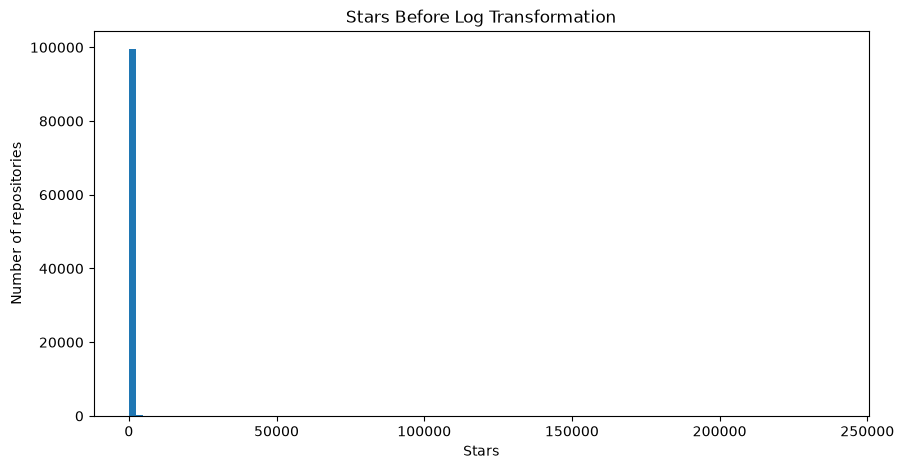

In [4]:
plt.figure(figsize=(10, 5))

plt.hist(df["stars"].sample(100000, random_state=42), bins=100)

plt.xlabel("Stars")
plt.ylabel("Number of repositories")
plt.title("Stars Before Log Transformation")

plt.show()

In [5]:
import numpy as np

df["stars_log"] = np.log1p(df["stars"])
df["forks_log"] = np.log1p(df["forks"])
df["watchers_log"] = np.log1p(df["watchers"])

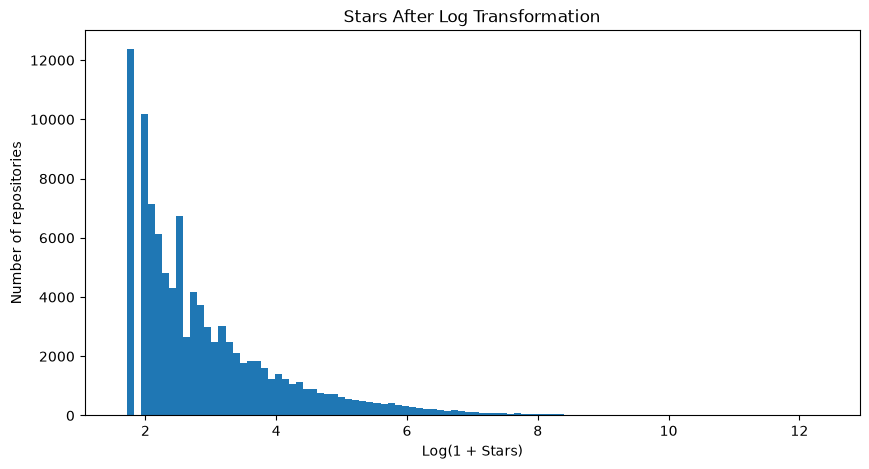

In [8]:
plt.figure(figsize=(10, 5))

plt.hist(df["stars_log"].sample(100000, random_state=42), bins=100)

plt.xlabel("Log(1 + Stars)")
plt.ylabel("Number of repositories")
plt.title("Stars After Log Transformation")

plt.show()

In [14]:
df.skew(numeric_only=True).sort_values(ascending=False)

forks            225.972939
stars            108.488262
watchers          78.921438
languageCount      9.339320
isArchived         3.667376
stars_log          1.737726
repo_age_days      1.643434
watchers_log       1.463543
forks_log          1.003311
isFork             0.000000
dtype: float64

In [15]:
df = df.drop(columns=["stars", "forks","watchers"])

In [33]:
df.skew(numeric_only=True).sort_values(ascending=False)

isArchived       3.667376
stars_log        1.737726
watchers_log     1.463543
forks_log        1.003311
languageCount    0.340094
isFork           0.000000
repo_age_days   -0.793180
dtype: float64

In [34]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
languageCount,4177100.0,1.060039,0.563655,0.000000,0.693147,1.098612,1.386294,6.194405
repo_age_days,4177100.0,5.015402,2.635255,0.000000,3.332205,5.918894,7.108244,8.713253
stars_log,4177100.0,2.946901,1.214398,1.609438,2.079442,2.564949,3.433987,12.964291
forks_log,4177100.0,1.621306,1.324696,0.000000,0.693147,1.386294,2.302585,12.402958
watchers_log,4177100.0,1.317960,0.848671,0.000000,0.693147,1.098612,1.609438,9.198268


In [35]:
df.to_csv("../data/merged/merged.csv", index=False)